<a href="https://colab.research.google.com/github/yashraj31102003/Capstone-Project/blob/main/Cardiovascular_Disease_Prediction_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫀 Cardiovascular Disease Prediction Using Machine Learning

<div align="center">

## Major Project

### Group No. 44

</div>

---

## 👥 Project Team

**Team Member 1:** Yash Raj
**Phone Number:** 7979045949

**Team Member 2:** Rahul A
**Phone Number:** 9843437320

**Team Member 3:** Hariharan J
**Phone Number:** 9345817945

**Team Member 4:** Maryam Maroof
**Phone Number:** +971503507034

---

### 📌 Project Information

| **Project Information**     | **Details**             |
| --------------------------- | ----------------------- |
| **Project Type**            | Major Project           |
| **Group No.**               | 44                      |
| **Domain**                  | Artificial Intelligence |
| **Development Environment** | Google Colab            |
| **Programming Language**    | Python                  |

---

### Project Overview

Cardiovascular disease is one of the major health challenges worldwide.

Early identification of individuals who may be at higher risk can support timely medical attention and preventive care.

This project focuses on developing a machine learning-based classification system to predict the presence of cardiovascular disease using patient demographic, physical, blood pressure, biochemical, and lifestyle-related information.

The project follows a complete machine learning workflow, beginning with dataset exploration and data preprocessing and continuing through exploratory data analysis, feature engineering, model development, evaluation, comparison, and final model selection.

The final system will also include a prediction pipeline that can be used to generate predictions for new patient records.

> **Disclaimer:** This project is developed for academic and educational purposes only. The predictions generated by the model should not be considered a medical diagnosis or a replacement for professional clinical judgment.


# 🎯 Project Objective

The primary objective of this project is to develop and evaluate machine
learning models capable of predicting cardiovascular disease from
patient-level health and lifestyle information.

The major objectives of the project are:

- Understand and preprocess the cardiovascular disease dataset.
- Identify and handle data-quality issues.
- Perform exploratory data analysis to understand important patterns.
- Create meaningful derived features such as age in years, BMI, and pulse pressure.
- Develop multiple machine learning classification models.
- Compare model performance using appropriate evaluation metrics.
- Apply stratified cross-validation for reliable model assessment.
- Evaluate the selected models on unseen test data.
- Analyze ROC-AUC and Precision-Recall performance.
- Study the confusion matrix and classification results.
- Identify important predictive features.
- Analyze different probability thresholds.
- Select the most suitable model for the project.
- Save the complete machine learning pipeline for future predictions.

# 🔄 Project Workflow

The project follows a structured end-to-end machine learning workflow.

**Dataset Collection → Data Loading → Data Understanding → Data Cleaning
→ Feature Engineering → Exploratory Data Analysis → Data Preprocessing
→ Train-Test Split → Model Development → Cross-Validation
→ Model Comparison → Model Evaluation → Explainability
→ Best Model Selection → Prediction Pipeline → Conclusion**

Each stage is performed systematically to improve the reliability,
interpretability, and reproducibility of the final machine learning system.

# 🛠️ Technologies and Libraries

This project is implemented using Python in Google Colab.

The major technologies and libraries used in the project include:

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib

Scikit-learn is used for data preprocessing, machine learning algorithms,
cross-validation, and model evaluation.

Pandas and NumPy are used for data manipulation and numerical operations.

Matplotlib and Seaborn are used to create visualizations for exploratory
data analysis and model evaluation.

Joblib is used to save the finalized machine learning pipeline.

In [ ]:
!pip -q install joblib scikit-learn seaborn

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve

from sklearn.inspection import permutation_importance

import joblib

RANDOM_STATE = 42

print("Environment initialized successfully.")
print("Random state:", RANDOM_STATE)

Environment initialized successfully.
Random state: 42


# 📝 Observation

The dataset was successfully loaded into the Google Colab environment.

The dataset contains 70,000 patient records and 13 variables. It includes
demographic, physical, blood pressure, biochemical, lifestyle, and target
information.

The target variable `cardio` represents the presence or absence of
cardiovascular disease.

The dataset is now ready for detailed data-quality analysis and exploratory
data analysis.

# 🔍 Dataset Structure and Data Understanding

The dataset structure is examined to understand the available variables,
their data types, and the overall organization of the patient records.

This step helps identify the predictor variables and the target variable
before beginning data preprocessing and exploratory analysis.

In [ ]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, sep=";")

print("Dataset loaded successfully.")
print("File name:", filename)
print("Number of records:", df.shape[0])
print("Number of features:", df.shape[1])

display(df.head())

Saving upload_2760543e-c9d3-4d81-a9c5-512450d17331.csv to upload_2760543e-c9d3-4d81-a9c5-512450d17331.csv
Dataset loaded successfully.
File name: upload_2760543e-c9d3-4d81-a9c5-512450d17331.csv
Number of records: 70000
Number of features: 13


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


# 🔍 Dataset Structure and Data Understanding

The dataset structure is examined to understand the available variables,
their data types, and the overall organization of the patient records.

This step helps identify the predictor variables and the target variable
before beginning data preprocessing and exploratory analysis.

In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame(name="Data Type"))

print("\nFirst Five Records:")
display(df.head())

print("\nLast Five Records:")
display(df.tail())

Dataset Shape:
(70000, 13)

Column Names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

Data Types:


,Data Type
id,int64
age,int64
gender,int64
height,int64
weight,float64
ap_hi,int64
ap_lo,int64
cholesterol,int64
gluc,int64
smoke,int64



First Five Records:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0



Last Five Records:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


# 📝 Observation

The dataset contains 70,000 patient records and 13 variables.

The variables represent demographic characteristics, physical measurements,
blood pressure, cholesterol, glucose, and lifestyle-related information.

The `cardio` variable is the target variable for predicting the presence
or absence of cardiovascular disease.

The `id` variable is an identifier and will not be used as a predictive
feature during model training.

The dataset structure has been successfully verified and is ready for
detailed data-quality analysis.

# 🔎 Missing Value Analysis

Missing-value analysis is performed to determine whether any patient
records contain incomplete information.

Identifying missing values before model development is important because
machine learning algorithms may not be able to directly process missing
observations.

The number and percentage of missing values are calculated for every
variable in the dataset.

In [ ]:
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

display(missing_summary)

,Missing Values,Missing Percentage
id,0,0.0
age,0,0.0
gender,0,0.0
height,0,0.0
weight,0,0.0
ap_hi,0,0.0
ap_lo,0,0.0
cholesterol,0,0.0
gluc,0,0.0
smoke,0,0.0


# 📝 Observation

The missing-value analysis shows that all 13 variables contain zero missing
values.

The dataset has a missing-value percentage of 0.0% for every variable.
Therefore, no observations need to be removed due to missing data.

The dataset is complete with respect to missing values and can proceed to
the next stage of data-quality analysis.

# 🔁 Duplicate Record Analysis

Duplicate records can introduce repeated observations and may affect the
reliability of statistical analysis and machine learning models.

The dataset is examined for completely duplicated rows before continuing
with further preprocessing.

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


# 📝 Observation

The duplicate-record analysis identified zero duplicate records in the
dataset.

Therefore, all patient observations are unique based on complete-row
comparison, and no records need to be removed due to duplication.

The dataset can proceed to statistical analysis and further data-quality
assessment.

# 📊 Statistical Summary

Descriptive statistical analysis is performed to understand the numerical
characteristics and distribution of the variables in the dataset.

Measures such as count, mean, standard deviation, minimum, maximum, and
quartiles are examined to identify the general range and variability of
patient attributes.

This analysis also helps identify variables that may contain unusual or
extreme values requiring further investigation during data cleaning.

In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


# 📝 Observation

The statistical summary shows that the dataset contains 70,000 complete
observations for all variables.

The age variable is recorded in days and ranges from 10,798 to 23,713 days,
so it will be converted into years during feature engineering.

The height and weight variables contain potentially unrealistic values.
More importantly, the blood-pressure variables contain extreme and
physiologically implausible values, with ap_hi ranging from -150 to 16,020
and ap_lo ranging from -70 to 11,000.

These observations indicate that data-quality filtering is required before
machine learning model development.

The cardio target has a mean close to 0.50, suggesting that the two target
classes are approximately balanced.

# 🎯 Target Variable Distribution

The target variable `cardio` represents the presence or absence of
cardiovascular disease.

A value of 0 represents the absence of cardiovascular disease, while a value
of 1 represents the presence of cardiovascular disease.

The distribution of both classes is examined using their absolute counts
and percentages to determine whether the classification problem is balanced
or imbalanced.

Target Class Distribution:

Cardio = 0: 35021 records (50.03%)
Cardio = 1: 34979 records (49.97%)


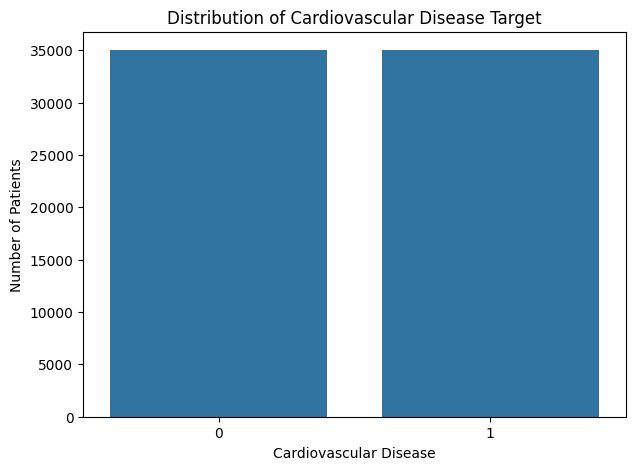

In [ ]:
target_counts = df["cardio"].value_counts().sort_index()
target_percentages = (df["cardio"].value_counts(normalize=True).sort_index() * 100).round(2)

print("Target Class Distribution:")
print()

for class_value in target_counts.index:
    print(
        f"Cardio = {class_value}: "
        f"{target_counts[class_value]} records "
        f"({target_percentages[class_value]}%)"
    )

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="cardio")
plt.title("Distribution of Cardiovascular Disease Target")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Number of Patients")
plt.show()

# 📝 Observation

The target variable is nearly perfectly balanced in the dataset.

The class representing no cardiovascular disease (cardio = 0) contains
35,021 records (50.03%), while the class representing cardiovascular
disease (cardio = 1) contains 34,979 records (49.97%).

The difference between the two classes is only 42 observations, indicating
that there is no significant class imbalance.

Therefore, no class-balancing technique is required solely on the basis of
the target distribution.

# 🧹 Data Cleaning and Quality Assessment

The statistical analysis identified several potentially unrealistic
measurements in the dataset, particularly in height, weight, and blood
pressure.

Data cleaning is performed to remove observations that fall outside
reasonable physiological ranges or violate basic measurement relationships.

The cleaning criteria are applied before feature engineering and model
development to improve the reliability of subsequent analysis.

In [ ]:
df_clean = df.copy()

df_clean["age_years"] = df_clean["age"] / 365.25

df_clean["bmi"] = (
    df_clean["weight"] /
    ((df_clean["height"] / 100) ** 2)
)

df_clean["pulse_pressure"] = (
    df_clean["ap_hi"] - df_clean["ap_lo"]
)

print("Original number of records:", len(df_clean))

print("\nRecords before cleaning:")
print(len(df_clean))

cleaning_mask = (
    df_clean["height"].between(120, 220) &
    df_clean["weight"].between(30, 250) &
    df_clean["ap_hi"].between(70, 250) &
    df_clean["ap_lo"].between(40, 150) &
    (df_clean["ap_hi"] >= df_clean["ap_lo"]) &
    df_clean["age_years"].between(10, 100) &
    df_clean["bmi"].between(10, 80)
)

df_clean = df_clean.loc[cleaning_mask].copy()

print("Records after cleaning:", len(df_clean))
print("Records removed:", len(df) - len(df_clean))
print("Percentage removed:", round((len(df) - len(df_clean)) / len(df) * 100, 2))

Original number of records: 70000

Records before cleaning:
70000
Records after cleaning: 68609
Records removed: 1391
Percentage removed: 1.99


# 📝 Observation

The data-cleaning procedure reduced the dataset from 70,000 to 68,609
records.

A total of 1,391 observations were removed, representing 1.99% of the
original dataset. Therefore, approximately 98.01% of the observations were
retained for further analysis.

The removed records contained measurements outside the predefined
acceptable ranges or violated the required relationship between systolic
and diastolic blood pressure.

The cleaned dataset provides a more reliable basis for feature engineering,
exploratory analysis, and subsequent machine learning model development.

# ⚙️ Feature Engineering

Feature engineering is performed to transform the existing variables into
more meaningful predictors for cardiovascular disease classification.

The age variable is converted from days into years to improve
interpretability.

Body Mass Index (BMI) is calculated from height and weight to represent
the patient's weight relative to height.

Pulse pressure is calculated as the difference between systolic and
diastolic blood pressure and provides an additional blood-pressure-related
predictor.

These engineered variables will be used alongside the original clinical,
demographic, and lifestyle variables during model development.

In [ ]:
print("Engineered Features:")

display(
    df_clean[
        ["age_years", "bmi", "pulse_pressure"]
    ].describe().T
)

print("\nSample of Engineered Features:")

display(
    df_clean[
        ["age", "age_years", "height", "weight", "bmi",
         "ap_hi", "ap_lo", "pulse_pressure", "cardio"]
    ].head(10)
)

Engineered Features:


,count,mean,std,min,25%,50%,75%,max
age_years,68609.0,53.291407,6.757204,29.563313,48.344969,53.941136,58.381930,64.922656
bmi,68609.0,27.454618,5.235074,10.726644,23.875115,26.346494,30.116213,69.534739
pulse_pressure,68609.0,45.366993,11.665794,0.000000,40.000000,40.000000,50.000000,140.000000



Sample of Engineered Features:


,age,age_years,height,weight,bmi,ap_hi,ap_lo,pulse_pressure,cardio
0,18393,50.357290,168,62.0,21.967120,110,80,30,0
1,20228,55.381246,156,85.0,34.927679,140,90,50,1
2,18857,51.627652,165,64.0,23.507805,130,70,60,1
3,17623,48.249144,169,82.0,28.710479,150,100,50,1
4,17474,47.841205,156,56.0,23.011177,100,60,40,0
5,21914,59.997262,151,67.0,29.384676,120,80,40,0
6,22113,60.542094,157,93.0,37.729725,130,80,50,0
7,22584,61.831622,178,95.0,29.983588,130,90,40,1
8,17668,48.372348,158,71.0,28.440955,110,70,40,0
9,19834,54.302533,164,68.0,25.282570,110,60,50,0


# 📝 Observation

Feature engineering was successfully completed on the cleaned dataset
containing 68,609 observations.

The mean patient age is approximately 53.29 years, with an observed range
of 29.56 to 64.92 years.

The mean BMI is approximately 27.45 kg/m², while the maximum BMI is
approximately 69.53 kg/m², indicating substantial variation in body
composition.

The mean pulse pressure is approximately 45.37 mmHg, with values ranging
from 0 to 140 mmHg.

The sample records confirm that the engineered age, BMI, and pulse-pressure
features have been calculated successfully from the original variables.

A pulse pressure of 0 is present in the cleaned data because the current
cleaning criterion permits observations where ap_hi is equal to ap_lo.

# 📈 Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution
and characteristics of important patient variables after data cleaning.

The analysis focuses on age, BMI, systolic blood pressure, diastolic blood
pressure, and cardiovascular disease status.

Understanding these distributions helps identify patterns, variability,
and relationships that may be relevant to cardiovascular disease
prediction.

## Distribution of Age and BMI

The distributions of patient age and BMI are visualized to examine their
overall patterns and variability within the cleaned dataset.

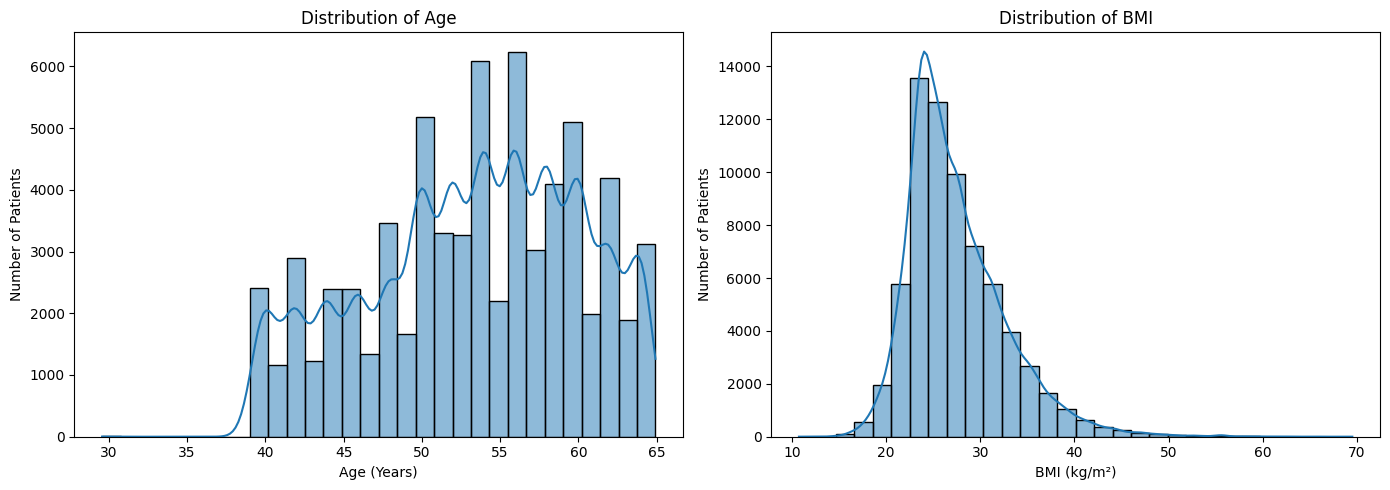

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean["age_years"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Age")
axes[0].set_xlabel("Age (Years)")
axes[0].set_ylabel("Number of Patients")

sns.histplot(df_clean["bmi"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribution of BMI")
axes[1].set_xlabel("BMI (kg/m²)")
axes[1].set_ylabel("Number of Patients")

plt.tight_layout()
plt.show()

# 📝 Observation

The age distribution is concentrated mainly between approximately 40 and
65 years, with higher frequencies observed across the 50 to 60 year range.

The BMI distribution is concentrated primarily between approximately 20 and
35 kg/m², with the highest frequency occurring in the mid-20s.

BMI exhibits a noticeable right-skewed distribution, with a longer tail
towards higher BMI values and a smaller number of observations above
approximately 40 kg/m².

Both age and BMI show substantial variation across the cleaned patient
population and may provide useful information for cardiovascular disease
prediction.

# 🩺 Blood Pressure Distribution Analysis

Blood pressure is an important clinical variable in cardiovascular disease
analysis.

The distributions of systolic blood pressure (`ap_hi`) and diastolic blood
pressure (`ap_lo`) are examined after data cleaning to understand their
central tendency, spread, and overall distribution within the patient
population.

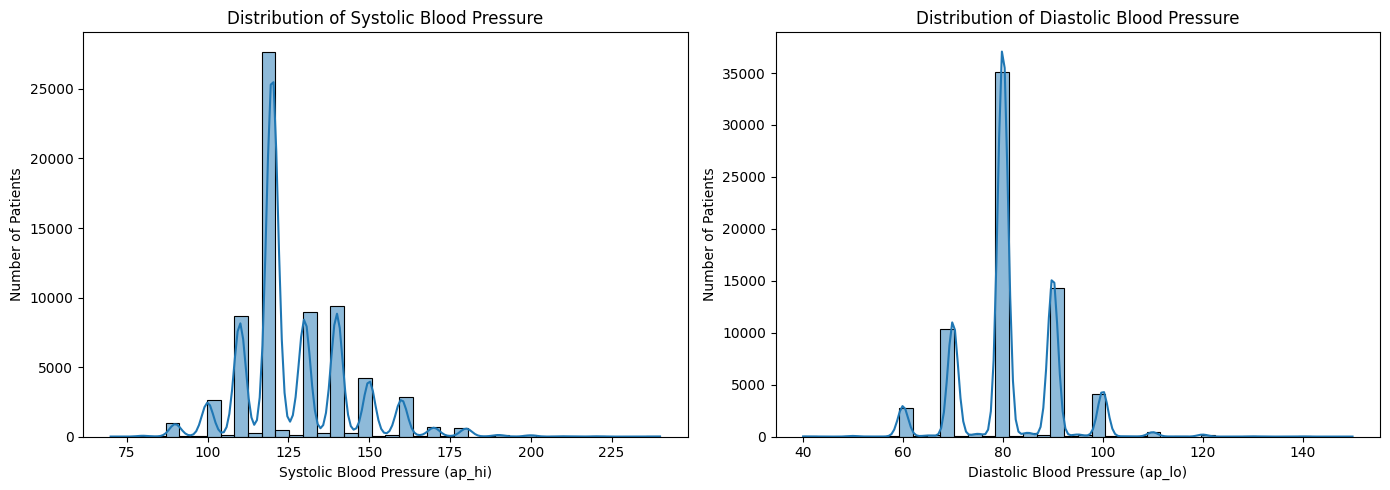

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean["ap_hi"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Systolic Blood Pressure")
axes[0].set_xlabel("Systolic Blood Pressure (ap_hi)")
axes[0].set_ylabel("Number of Patients")

sns.histplot(df_clean["ap_lo"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Diastolic Blood Pressure")
axes[1].set_xlabel("Diastolic Blood Pressure (ap_lo)")
axes[1].set_ylabel("Number of Patients")

plt.tight_layout()
plt.show()

# 📝 Observation

The blood-pressure analysis shows that systolic blood pressure is
concentrated mainly between approximately 110 and 140 mmHg, with the
largest concentration occurring around 120 mmHg.

Diastolic blood pressure is strongly concentrated around 80 mmHg, with
additional concentrations around 70 and 90 mmHg.

The cleaning procedure has substantially reduced the extreme blood-pressure
values observed in the original dataset.

Both variables show distinct peaks because blood-pressure measurements are
recorded at specific integer values.

The observed variation in systolic and diastolic blood pressure makes these
variables potentially important predictors of cardiovascular disease.

## Blood Pressure by Cardiovascular Disease Status

The relationship between blood pressure and cardiovascular disease is
examined by comparing systolic and diastolic blood-pressure distributions
between patients with and without cardiovascular disease.

Box plots are used to compare the central tendency and variability of blood
pressure across the two target classes.

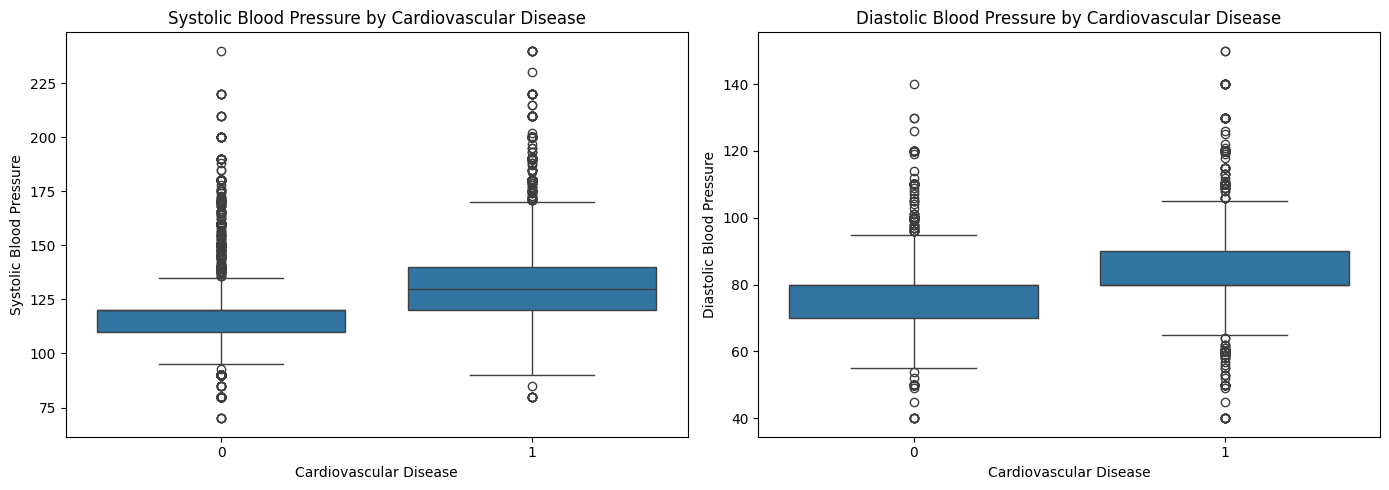

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x="cardio", y="ap_hi", ax=axes[0])
axes[0].set_title("Systolic Blood Pressure by Cardiovascular Disease")
axes[0].set_xlabel("Cardiovascular Disease")
axes[0].set_ylabel("Systolic Blood Pressure")

sns.boxplot(data=df_clean, x="cardio", y="ap_lo", ax=axes[1])
axes[1].set_title("Diastolic Blood Pressure by Cardiovascular Disease")
axes[1].set_xlabel("Cardiovascular Disease")
axes[1].set_ylabel("Diastolic Blood Pressure")

plt.tight_layout()
plt.show()

# 📝 Observation

The box-plot analysis shows a clear difference in blood-pressure levels
between patients with and without cardiovascular disease.

Patients with cardiovascular disease generally have higher systolic blood
pressure, with the median located around 130 mmHg, compared with
approximately 115 to 120 mmHg among patients without cardiovascular
disease.

Diastolic blood pressure also tends to be higher among patients with
cardiovascular disease, with a median around 90 mmHg compared with
approximately 80 mmHg for patients without cardiovascular disease.

Both groups contain several observations outside the main interquartile
ranges, particularly at higher blood-pressure levels.

The observed separation between the two target groups indicates that blood
pressure may be an important predictor of cardiovascular disease.

## BMI by Cardiovascular Disease Status

The relationship between Body Mass Index (BMI) and cardiovascular disease
is examined by comparing BMI distributions across the two target classes.

Box plots are used to determine whether differences in BMI are observable
between patients with and without cardiovascular disease.

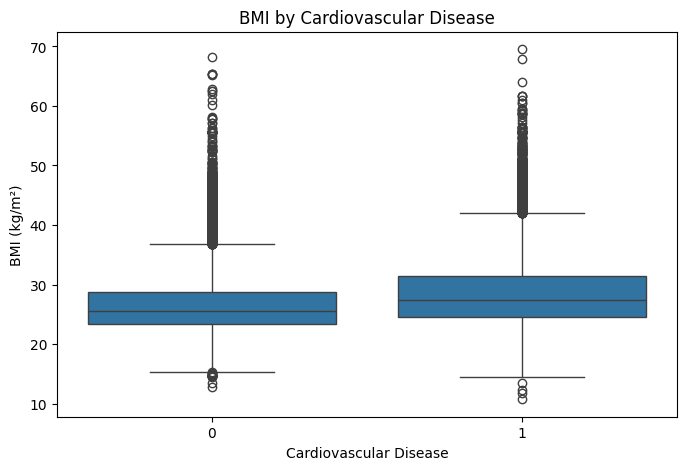

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="cardio",
    y="bmi"
)

plt.title("BMI by Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("BMI (kg/m²)")
plt.show()

# 📝 Observation

The BMI comparison shows that patients with cardiovascular disease generally
have higher BMI values than patients without cardiovascular disease.

The median BMI for the cardio = 0 group is approximately 25 to 26 kg/m²,
while the median BMI for the cardio = 1 group is approximately 27 to
28 kg/m².

The cardio = 1 group also shows a somewhat wider distribution of BMI values.

Both groups contain several high-BMI observations, with values extending
above 40 kg/m² and reaching close to 70 kg/m².

The overlap between the two groups indicates that BMI alone cannot clearly
separate patients with and without cardiovascular disease, but it may
provide useful predictive information when combined with other features.

## Age by Cardiovascular Disease Status

Age is an important demographic variable for cardiovascular risk analysis.

The distribution of patient age is compared between the two cardiovascular
disease classes to determine whether differences in age are observable
between patients with and without cardiovascular disease.

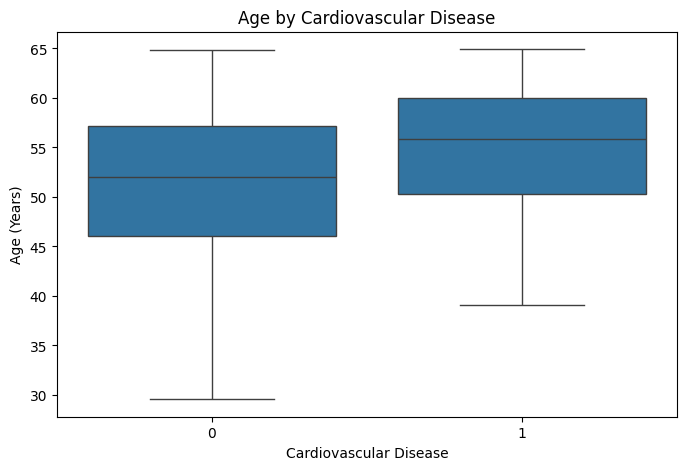

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="cardio",
    y="age_years"
)

plt.title("Age by Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Age (Years)")
plt.show()

# 📝 Observation

The age comparison shows that patients with cardiovascular disease generally
tend to be older than patients without cardiovascular disease.

The median age of the cardio = 0 group is approximately 52 years, while the
median age of the cardio = 1 group is approximately 56 years.

The middle 50% of the cardiovascular-disease group is shifted toward higher
ages compared with the non-disease group.

The observed difference suggests that age may be an important predictor of
cardiovascular disease when combined with other clinical and lifestyle
variables.

# 🧬 Categorical Feature Analysis

Several variables in the dataset represent categorical or binary patient
characteristics rather than continuous measurements.

The distributions of gender, cholesterol level, glucose level, smoking,
alcohol consumption, and physical activity are examined with respect to
cardiovascular disease status.

This analysis helps identify differences in these characteristics between
patients with and without cardiovascular disease.

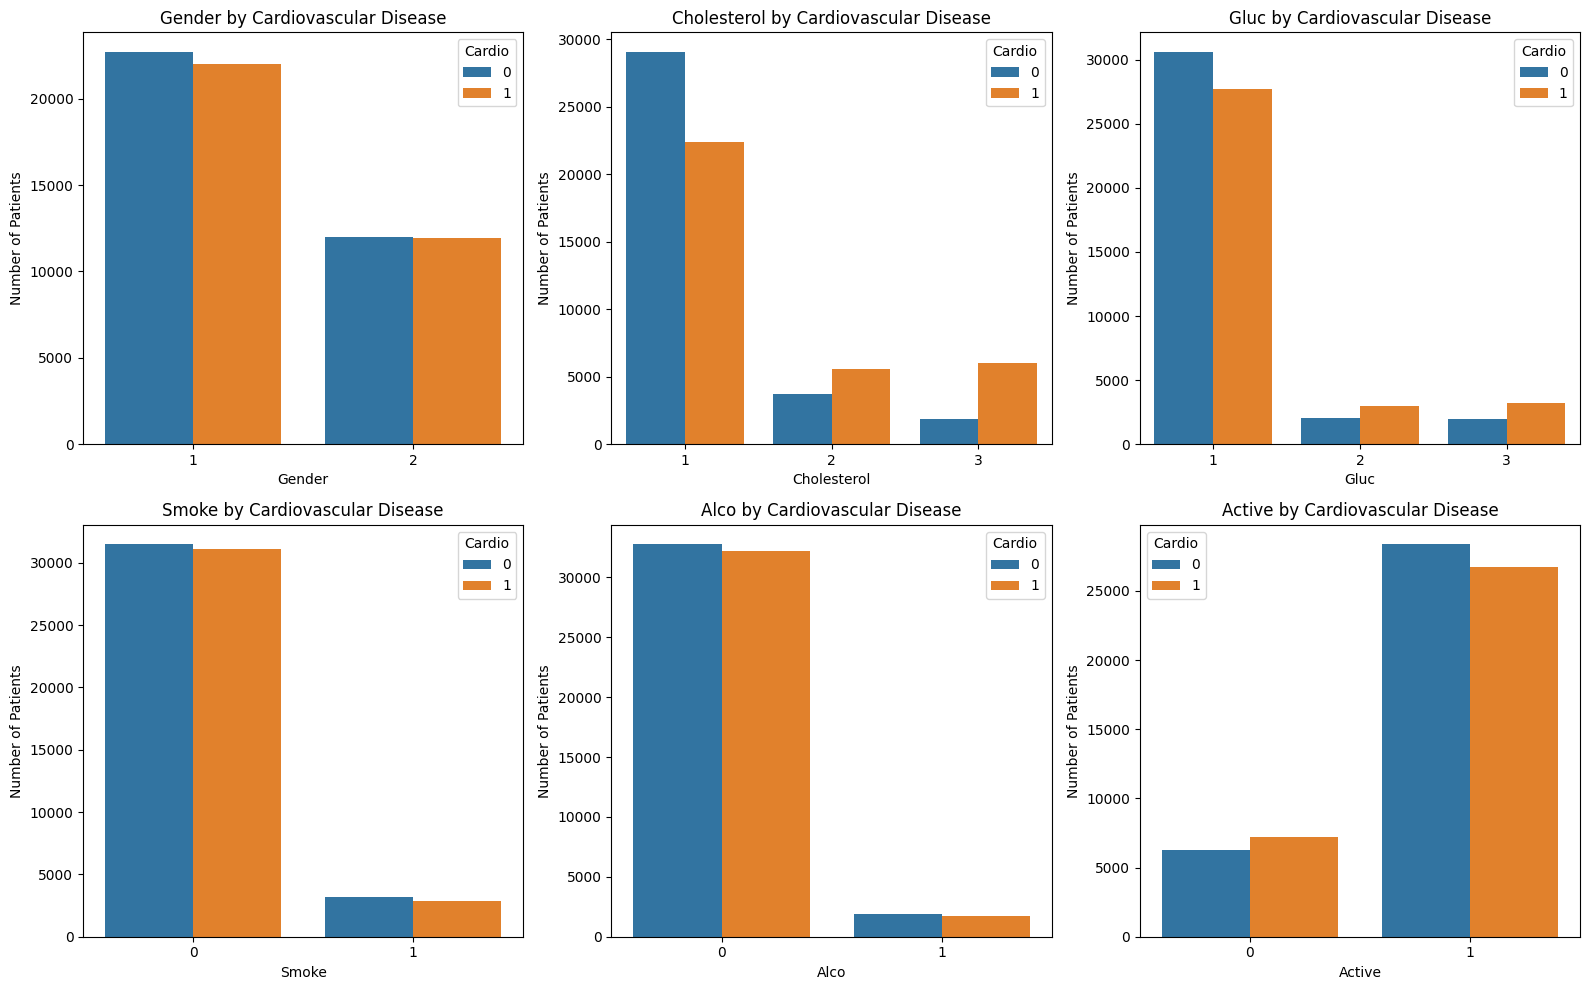

In [ ]:
categorical_features = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, feature in zip(axes.flat, categorical_features):
    sns.countplot(
        data=df_clean,
        x=feature,
        hue="cardio",
        ax=ax
    )
    ax.set_title(f"{feature.capitalize()} by Cardiovascular Disease")
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel("Number of Patients")
    ax.legend(title="Cardio")

plt.tight_layout()
plt.show()

# 📝 Observation

The categorical-feature analysis shows differences in several patient
characteristics between the cardiovascular disease groups.

The cholesterol distribution shows a greater presence of higher cholesterol
categories among patients with cardiovascular disease.

Similarly, higher glucose categories appear relatively more frequently among
patients with cardiovascular disease compared with patients without
cardiovascular disease.

Most patients are non-smokers and report no alcohol consumption, with
relatively similar distributions between the two cardiovascular disease
groups.

Most patients are physically active; however, the cardiovascular disease
group shows a somewhat higher presence of inactive patients.

Overall, cholesterol, glucose, and physical activity show more noticeable
differences between the target groups in the exploratory analysis.

# 🔗 Correlation Analysis

Correlation analysis is performed to examine the linear relationships
between numerical variables in the cleaned dataset.

A correlation matrix is visualized using a heatmap to identify the strength
and direction of relationships between patient characteristics and the
cardiovascular disease target.

The analysis provides an initial understanding of which variables may have
stronger associations with the target variable.

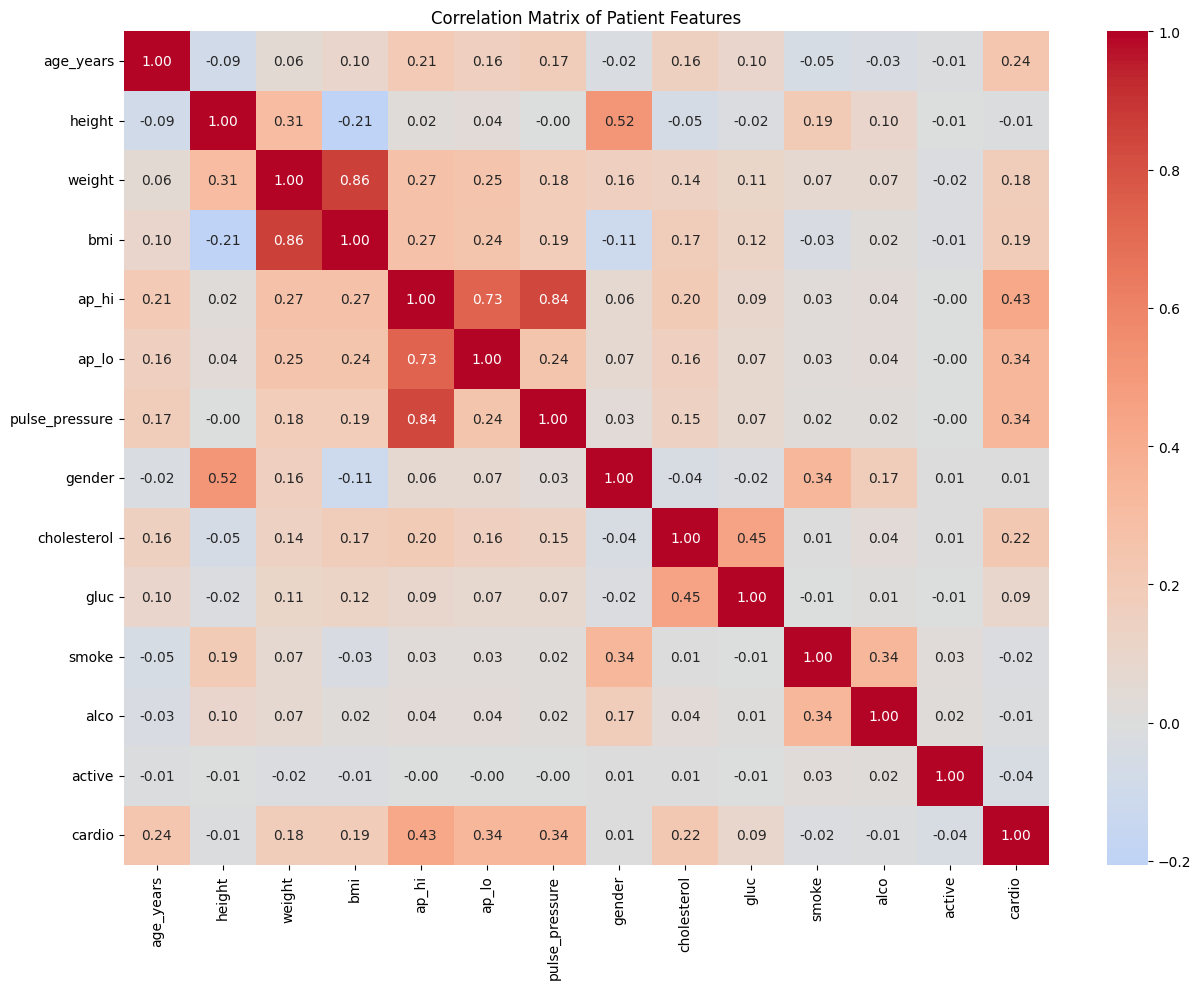

In [ ]:
correlation_features = [
    "age_years",
    "height",
    "weight",
    "bmi",
    "ap_hi",
    "ap_lo",
    "pulse_pressure",
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "cardio"
]

correlation_matrix = df_clean[correlation_features].corr()

plt.figure(figsize=(13, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Patient Features")
plt.tight_layout()
plt.show()

# 📝 Observation

The correlation analysis shows that systolic blood pressure (ap_hi) has the
strongest positive correlation with the cardiovascular disease target,
with a correlation coefficient of 0.43.

Diastolic blood pressure (ap_lo) and pulse pressure both show moderate
positive correlations of 0.34 with the target. Age also has a positive
association with cardiovascular disease, with a correlation of 0.24.

Cholesterol, BMI, and weight show weaker positive relationships with the
target, with correlation coefficients of 0.22, 0.19, and 0.18 respectively.

Glucose has a relatively weak positive correlation of 0.09, while physical
activity, smoking, and alcohol consumption show weak correlations with the
target.

A strong correlation is observed between weight and BMI (0.86), and between
systolic blood pressure and pulse pressure (0.84), which is expected because
the engineered variables are mathematically related to the original
measurements.

Correlation indicates association rather than causation, so the machine
learning models will be used to evaluate the combined predictive value of
the features.

# 📊 Scatter Plot Analysis

Scatter plots are used to examine relationships between important continuous
variables and cardiovascular disease status.

The analysis focuses on age, BMI, and systolic blood pressure to provide
additional visual insight into the relationships identified during the
exploratory data analysis.

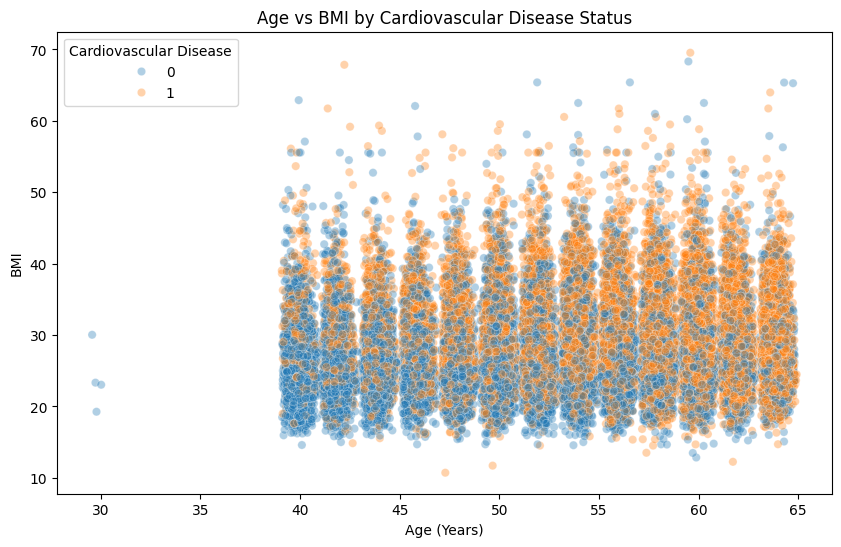

In [43]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="age_years",
    y="bmi",
    hue="cardio",
    alpha=0.35
)

plt.title("Age vs BMI by Cardiovascular Disease Status")
plt.xlabel("Age (Years)")
plt.ylabel("BMI")
plt.legend(title="Cardiovascular Disease")
plt.show()

# Observation

The scatter plot of Age vs BMI provides a visual comparison of these two continuous variables across cardiovascular disease status. The points show substantial overlap between the two classes, indicating that age and BMI together do not provide a completely distinct separation between patients with and without cardiovascular disease.

The plot also supports the earlier EDA findings that cardiovascular disease is more commonly observed among older individuals and that higher BMI values are present in both groups. Therefore, age and BMI may contribute to cardiovascular disease prediction, but neither variable alone clearly separates the two classes.

Next, let's add the more important scatter plot: Age vs Systolic Blood Pressure, which should provide a clearer view of the relationship between two major predictive factors.

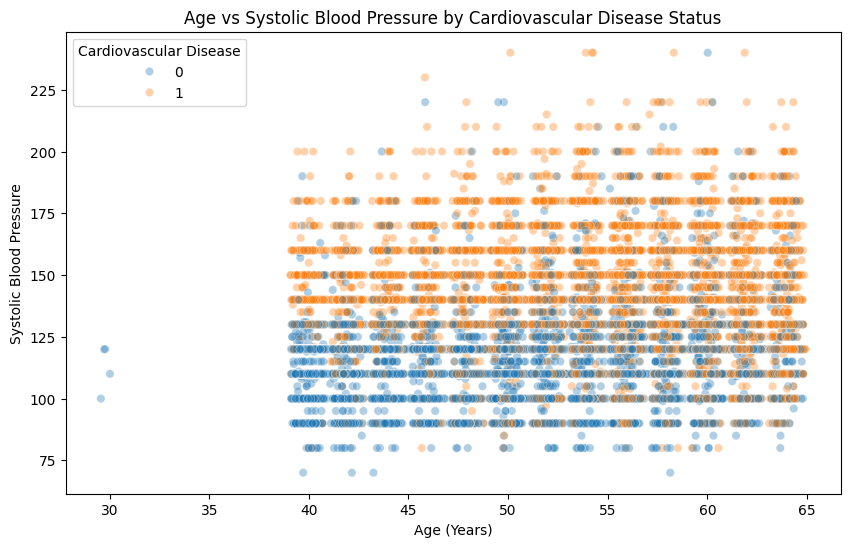

In [44]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="age_years",
    y="ap_hi",
    hue="cardio",
    alpha=0.35
)

plt.title("Age vs Systolic Blood Pressure by Cardiovascular Disease Status")
plt.xlabel("Age (Years)")
plt.ylabel("Systolic Blood Pressure")
plt.legend(title="Cardiovascular Disease")
plt.show()

#Observation

The Age vs Systolic Blood Pressure scatter plot shows substantial overlap between the two cardiovascular disease classes. However, observations with cardiovascular disease tend to appear more frequently at higher systolic blood pressure values, particularly among older individuals.

This is consistent with the earlier correlation analysis, where systolic blood pressure (ap_hi) had the strongest correlation with cardiovascular disease (0.43). The plot therefore provides additional visual support that systolic blood pressure is an important predictive feature.

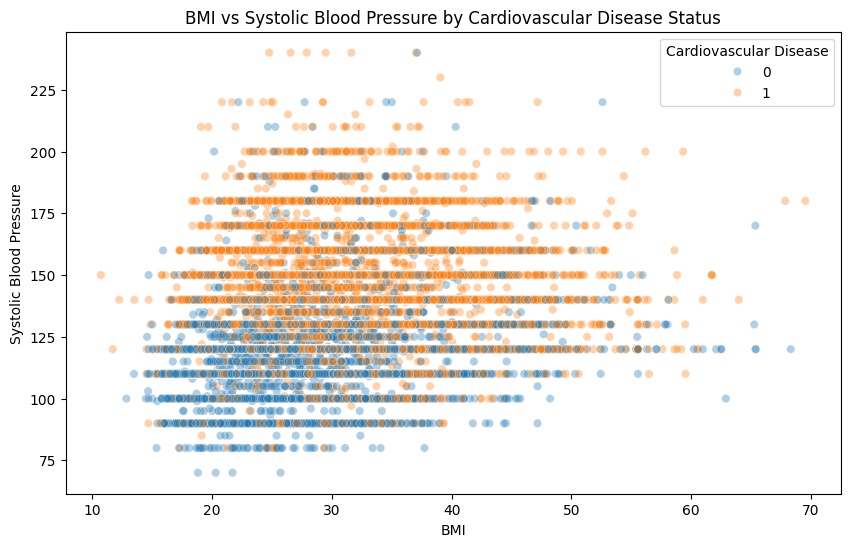

In [45]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="bmi",
    y="ap_hi",
    hue="cardio",
    alpha=0.35
)

plt.title("BMI vs Systolic Blood Pressure by Cardiovascular Disease Status")
plt.xlabel("BMI")
plt.ylabel("Systolic Blood Pressure")
plt.legend(title="Cardiovascular Disease")
plt.show()

#Observation

The BMI vs Systolic Blood Pressure scatter plot shows considerable overlap between the two cardiovascular disease classes. However, cardiovascular disease cases appear more frequently in regions with higher systolic blood pressure, while the relationship between BMI and systolic blood pressure itself is less clearly separated.

This suggests that systolic blood pressure provides a stronger visual distinction between the target classes than BMI, supporting the earlier finding that ap_hi is the most influential feature in the final model.

# 🤖 Machine Learning Preparation

The cleaned dataset is prepared for machine learning model development.

The identifier variable `id` is excluded because it represents a patient
identifier rather than a meaningful predictive characteristic.

The target variable `cardio` is separated from the predictor variables.

The remaining variables are divided into training and testing sets using a
stratified split so that the cardiovascular disease class distribution is
preserved in both subsets.

In [ ]:
X = df_clean.drop(columns=["id", "cardio"])
y = df_clean["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Machine Learning Dataset:")
print("Total records:", len(X))
print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Number of predictor variables:", X.shape[1])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(4))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(4))

Machine Learning Dataset:
Total records: 68609
Training records: 54887
Testing records: 13722
Number of predictor variables: 14

Training target distribution:
cardio
0    0.5053
1    0.4947
Name: proportion, dtype: float64

Testing target distribution:
cardio
0    0.5053
1    0.4947
Name: proportion, dtype: float64


# 📝 Observation

The dataset was successfully divided into training and testing subsets using
a stratified 80:20 split.

The cleaned dataset contains 68,609 observations, of which 54,887
observations are used for training and 13,722 observations are reserved
for testing.

There are 14 predictor variables after excluding the patient identifier and
target variable.

The training and testing datasets both preserve the same target
distribution, with 50.53% belonging to cardio = 0 and 49.47% belonging to
cardio = 1.

This confirms that the stratified split has maintained the class
distribution consistently across both datasets.

# ⚙️ Feature Preprocessing

Machine learning algorithms require the input variables to be represented
in an appropriate numerical form.

The predictor variables are divided into numerical and categorical
features.

Numerical variables are standardized so that variables measured on
different scales can be processed consistently, which is particularly
important for models such as Logistic Regression, SVM, and KNN.

Categorical variables are encoded using one-hot encoding while preserving
unseen-category handling for future predictions.

A preprocessing pipeline is created so that the same transformations are
applied consistently during training, validation, testing, and future
patient prediction.

In [ ]:
numerical_features = [
    "age_years",
    "height",
    "weight",
    "bmi",
    "ap_hi",
    "ap_lo",
    "pulse_pressure"
]

categorical_features = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_features
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ))
            ]),
            categorical_features
        )
    ],
    remainder="drop"
)

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Total input features:", len(numerical_features) + len(categorical_features))
print("Preprocessing pipeline created successfully.")

Numerical features: 7
Categorical features: 6
Total input features: 13
Preprocessing pipeline created successfully.


# 📝 Observation

The preprocessing pipeline was successfully created with seven numerical
features and six categorical features.

Numerical variables will be median-imputed and standardized, while
categorical variables will be imputed using the most frequent value and
transformed using one-hot encoding.

The pipeline contains 13 original predictor variables before categorical
encoding.

The preprocessing workflow ensures that the same transformations can be
applied consistently during model training, evaluation, and future
predictions.

# 🤖 Machine Learning Model Development

Multiple supervised machine learning classification algorithms are
developed to predict the presence of cardiovascular disease.

The selected models represent different learning approaches, including
linear classification, ensemble learning, distance-based classification,
kernel-based classification, and gradient-based boosting.

The models include Logistic Regression, Random Forest, Extra Trees, Support
Vector Machine, K-Nearest Neighbors, and HistGradientBoosting.

Each model will be integrated with the preprocessing pipeline to ensure
that data transformation is performed consistently without information
leakage.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=15,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    )
}

pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

print("Number of models:", len(pipelines))
print("\nModels:")
for name in pipelines:
    print("-", name)

Number of models: 6

Models:
- Logistic Regression
- Random Forest
- Extra Trees
- SVM
- KNN
- HistGradientBoosting


# 📝 Observation

Six supervised classification models were successfully configured for
cardiovascular disease prediction.

The selected algorithms represent linear, ensemble, kernel-based,
distance-based, and gradient-boosting approaches.

Each model has been integrated with the common preprocessing pipeline,
ensuring consistent preprocessing during model training and evaluation.

The models are ready for comparative evaluation using stratified
cross-validation.

# 🔄 Stratified 5-Fold Cross-Validation

Stratified 5-fold cross-validation is used to obtain a robust estimate of
model performance on the training dataset.

The training data is divided into five folds while preserving the
proportion of cardiovascular disease classes within each fold.

Each model is trained on four folds and evaluated on the remaining fold.
This process is repeated five times so that every observation is used for
validation exactly once.

Multiple evaluation metrics are calculated to provide a comprehensive
assessment of classification performance.

In [ ]:
pipelines = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=150,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Extra Trees": Pipeline([
        ("preprocessor", preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=150,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "SVM": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SVC(
            kernel="rbf",
            probability=False,
            random_state=RANDOM_STATE
        ))
    ]),

    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(
            n_neighbors=15,
            n_jobs=-1
        ))
    ]),

    "HistGradientBoosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.08,
            max_leaf_nodes=31,
            random_state=RANDOM_STATE
        ))
    ])
}

print("Optimized model pipelines configured successfully.")

Optimized model pipelines configured successfully.


In [28]:
fast_pipelines = {
    "Logistic Regression": pipelines["Logistic Regression"],
    "Random Forest": pipelines["Random Forest"],
    "HistGradientBoosting": pipelines["HistGradientBoosting"]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_results = []

for name, pipeline in fast_pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC": scores["test_pr_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

display(
    cv_results_df.sort_values(
        "ROC-AUC",
        ascending=False
    ).reset_index(drop=True).round(4)
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,HistGradientBoosting,0.7352,0.7347,0.7551,0.6879,0.7199,0.7991,0.7807
1,Logistic Regression,0.7271,0.7264,0.7542,0.6650,0.7068,0.7905,0.7701
2,Random Forest,0.7098,0.7096,0.7124,0.6931,0.7026,0.7696,0.7503


## Observation

The cross-validation results show that HistGradientBoosting achieved the best overall performance among the evaluated models, with an accuracy of 73.52%, balanced accuracy of 73.47%, F1 score of 71.99%, ROC-AUC of 79.91%, and PR-AUC of 78.07%.

Logistic Regression also performed well, achieving 72.71% accuracy and a ROC-AUC of 79.05%, while Random Forest showed comparatively lower performance across most evaluation metrics.

Overall, HistGradientBoosting provided the strongest balance between classification performance and ranking ability, making it the leading candidate for further evaluation on the test dataset.

# 🧪 Test Set Model Evaluation

After cross-validation, the trained models are evaluated on the unseen test
dataset to measure their generalization performance.

The evaluation focuses on accuracy, precision, recall, F1 score, ROC-AUC, and
PR-AUC. These metrics provide a comprehensive assessment of the models'
ability to correctly identify patients with and without cardiovascular disease.

In [29]:
test_results = []

for name, pipeline in fast_pipelines.items():
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

test_results_df = pd.DataFrame(test_results)

display(
    test_results_df.sort_values(
        "ROC-AUC",
        ascending=False
    ).reset_index(drop=True).round(4)
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,HistGradientBoosting,0.7363,0.7358,0.7572,0.6874,0.7206,0.8052,0.7844
1,Logistic Regression,0.7299,0.7292,0.7586,0.6659,0.7092,0.7962,0.7755
2,Random Forest,0.7128,0.7127,0.7140,0.6996,0.7067,0.7706,0.7519


## Observation

The test-set results show that HistGradientBoosting achieved the strongest
overall performance, with an accuracy of 73.63%, balanced accuracy of 73.58%,
F1 score of 72.06%, ROC-AUC of 80.52%, and PR-AUC of 78.44%.

Logistic Regression achieved 72.99% accuracy and a ROC-AUC of 79.62%, showing
competitive performance. Random Forest achieved the highest recall at 69.96%,
but its overall accuracy, F1 score, ROC-AUC, and PR-AUC were lower than the
other evaluated models.

The results indicate that HistGradientBoosting is currently the strongest
candidate for the final cardiovascular disease prediction model.

# 🧩 Confusion Matrix Analysis

A confusion matrix is used to evaluate the classification performance of the
selected HistGradientBoosting model by comparing the actual cardiovascular
disease classes with the predicted classes.

It shows the number of true positives, true negatives, false positives, and
false negatives, providing a detailed view of the model's classification
performance.

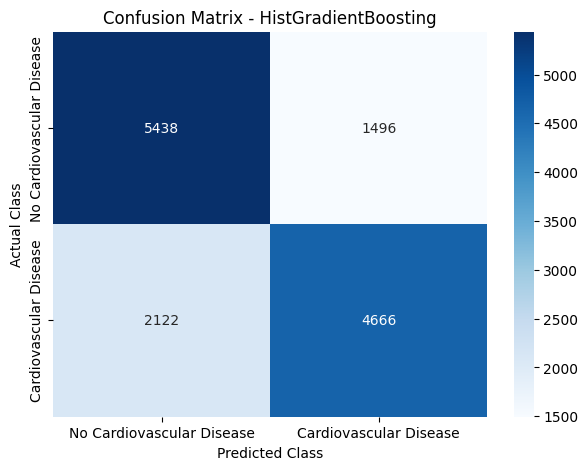

In [30]:
best_model = fast_pipelines["HistGradientBoosting"]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Cardiovascular Disease", "Cardiovascular Disease"],
    yticklabels=["No Cardiovascular Disease", "Cardiovascular Disease"]
)

plt.title("Confusion Matrix - HistGradientBoosting")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

## Observation

The confusion matrix shows that the HistGradientBoosting model correctly
classified 5,438 patients without cardiovascular disease and 4,666 patients
with cardiovascular disease.

The model incorrectly classified 1,496 patients without cardiovascular disease
as having cardiovascular disease, while 2,122 patients with cardiovascular
disease were incorrectly classified as not having the disease.

Overall, the model correctly classified a substantial number of both classes,
with the number of true positives higher than the number of false negatives.
This indicates that the model has a reasonable ability to identify patients
with cardiovascular disease.

# 📈 ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the
ability of the selected HistGradientBoosting model to distinguish between
patients with and without cardiovascular disease.

The ROC curve compares the true positive rate with the false positive rate
across different classification thresholds. The Area Under the ROC Curve
(ROC-AUC) provides a summary measure of the model's discrimination ability.

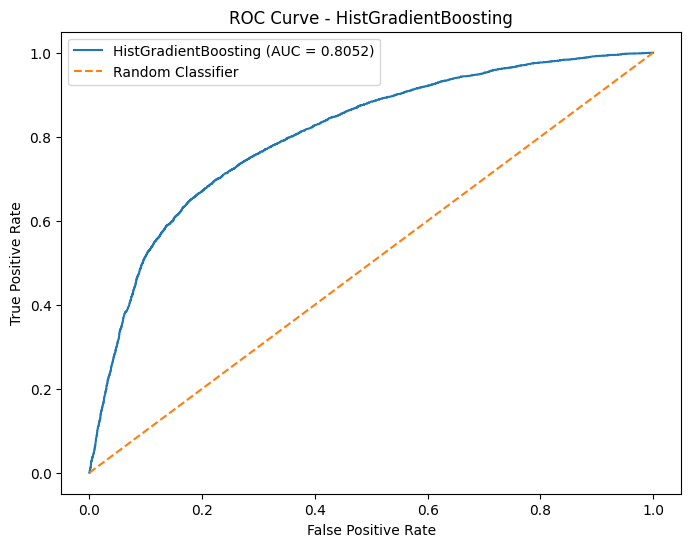

ROC-AUC Score: 0.8052


In [31]:
y_prob_best = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
roc_auc = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"HistGradientBoosting (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - HistGradientBoosting")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

## Observation

The ROC curve shows that the HistGradientBoosting model performs substantially
better than a random classifier, as the curve remains well above the diagonal
reference line.

The model achieved a ROC-AUC score of 0.8052, indicating good ability to
distinguish between patients with and without cardiovascular disease across
different classification thresholds.

The curve demonstrates that the model can achieve a relatively high true
positive rate while maintaining a comparatively lower false positive rate,
showing useful discriminative performance.

# 🎯 Precision-Recall Curve Analysis

The Precision-Recall curve is used to evaluate the relationship between
precision and recall at different classification thresholds.

This analysis provides a detailed assessment of the model's ability to
identify patients with cardiovascular disease while considering both
correct positive predictions and missed positive cases.

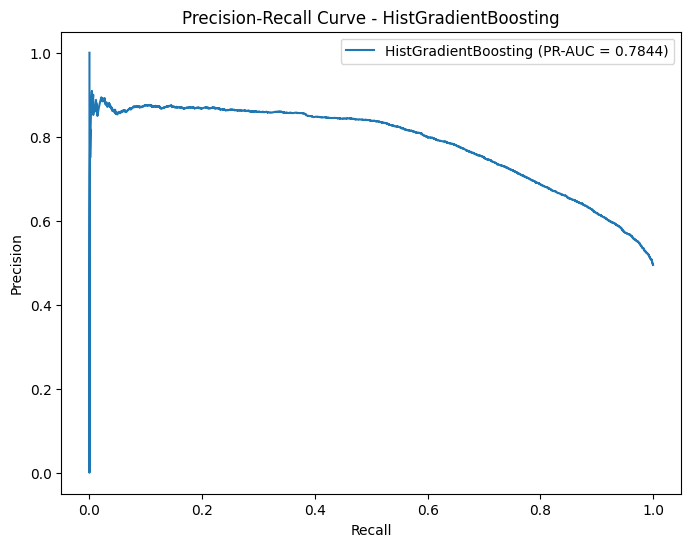

PR-AUC Score: 0.7844


In [32]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_best
)

pr_auc = average_precision_score(
    y_test,
    y_prob_best
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"HistGradientBoosting (PR-AUC = {pr_auc:.4f})"
)

plt.title("Precision-Recall Curve - HistGradientBoosting")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

print(f"PR-AUC Score: {pr_auc:.4f}")

## Observation

The Precision-Recall curve shows that the HistGradientBoosting model maintains
good precision across a wide range of recall values.

The model achieved a PR-AUC score of 0.7844, indicating good performance in
identifying patients with cardiovascular disease while maintaining a useful
level of precision.

As recall increases toward higher values, precision gradually decreases,
showing the expected trade-off between identifying more positive cases and
avoiding false positive predictions.

# 🔍 Feature Importance Analysis

Feature importance analysis is used to understand which patient characteristics
contribute most to the predictions made by the selected HistGradientBoosting
model.

Permutation importance is used to measure the contribution of each feature by
observing the change in model performance when the feature values are randomly
shuffled.

In [34]:
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(importance_df.round(4))

,Feature,Importance
0,ap_hi,0.1881
1,age_years,0.0394
2,cholesterol,0.0322
3,weight,0.0026
4,bmi,0.0023
5,ap_lo,0.0021
6,active,0.0020
7,gluc,0.0012
8,smoke,0.0008
9,alco,0.0004


## Observation

The permutation importance analysis shows that systolic blood pressure
(`ap_hi`) is the most influential feature for the HistGradientBoosting model,
with an importance score of 0.1881.

Age in years and cholesterol are the next most influential features, with
importance scores of 0.0394 and 0.0322 respectively. Weight, BMI, diastolic
blood pressure, and physical activity have comparatively smaller contributions.

The original age feature has an importance of 0.0000 because age_years is
already included as an engineered representation of the same information.
Overall, the results indicate that blood pressure, age, and cholesterol are
the most influential features for the model's predictions.

# 📊 Feature Importance Visualization

The feature importance scores are visualized to provide a clearer comparison
of the relative contribution of the input features to the HistGradientBoosting
model's predictions.

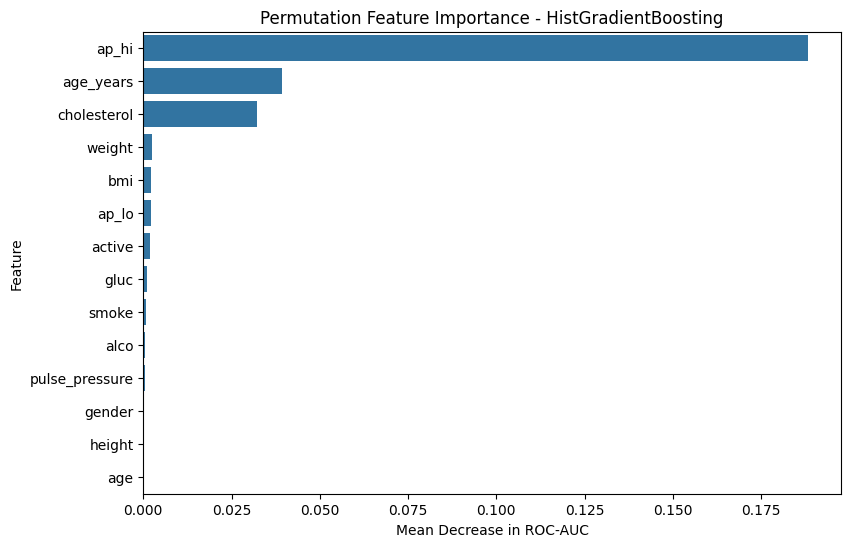

In [35]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance - HistGradientBoosting")
plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.show()

# 📊 Model Performance Comparison

The performance of the evaluated machine learning models is compared using
accuracy, F1 score, and ROC-AUC.

These metrics provide a balanced view of overall classification performance,
prediction quality, and the ability of the models to distinguish between the
two cardiovascular disease classes.

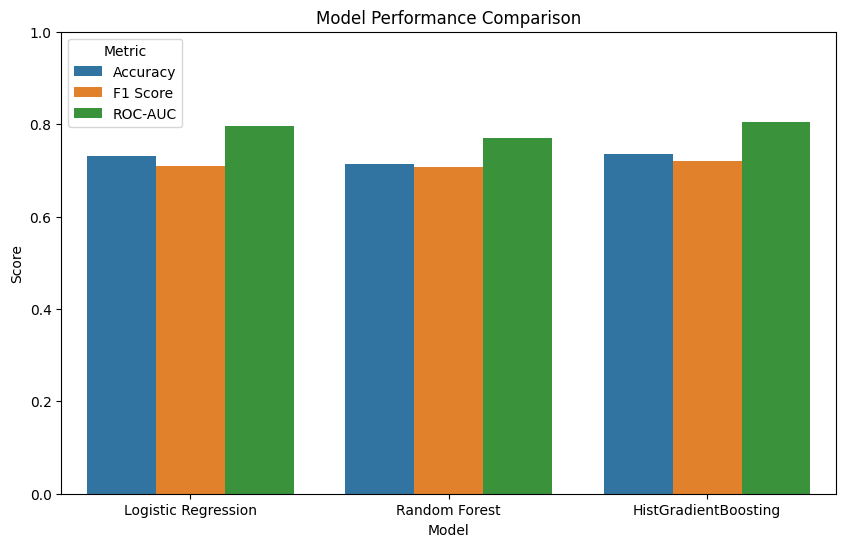

In [36]:
comparison_metrics = test_results_df[
    ["Model", "Accuracy", "F1 Score", "ROC-AUC"]
].copy()

comparison_metrics = comparison_metrics.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_metrics,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.show()

## Observation

The comparison shows that HistGradientBoosting achieved the best overall
performance among the evaluated models, with the highest accuracy, F1 score,
and ROC-AUC.

HistGradientBoosting achieved an accuracy of 73.63%, an F1 score of 72.06%,
and a ROC-AUC of 80.52%. Logistic Regression showed competitive performance,
while Random Forest recorded comparatively lower overall scores.

Based on these results, HistGradientBoosting is selected as the best-performing
model for cardiovascular disease prediction in this study.

# 📋 Classification Report

The classification report provides a detailed evaluation of the selected
HistGradientBoosting model for each cardiovascular disease class.

It includes precision, recall, and F1-score, allowing the performance of the
model to be examined separately for patients with and without cardiovascular
disease.

In [37]:
print("Classification Report - HistGradientBoosting")

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=[
            "No Cardiovascular Disease",
            "Cardiovascular Disease"
        ]
    )
)

Classification Report - HistGradientBoosting
                           precision    recall  f1-score   support

No Cardiovascular Disease       0.72      0.78      0.75      6934
   Cardiovascular Disease       0.76      0.69      0.72      6788

                 accuracy                           0.74     13722
                macro avg       0.74      0.74      0.74     13722
             weighted avg       0.74      0.74      0.74     13722



## Observation

The classification report shows that the HistGradientBoosting model achieved
an overall accuracy of approximately 74%.

For patients without cardiovascular disease, the model achieved a precision
of 0.72, recall of 0.78, and F1-score of 0.75. For patients with
cardiovascular disease, it achieved a precision of 0.76, recall of 0.69, and
F1-score of 0.72.

The model therefore identifies patients without cardiovascular disease more
effectively in terms of recall, while its precision is slightly higher for
the cardiovascular disease class. The macro and weighted averages are both
approximately 0.74, indicating reasonably balanced performance across the
two classes.

# Final Model Summary

Based on the cross-validation and test-set evaluation, HistGradientBoosting
was selected as the best-performing model for cardiovascular disease
prediction.

The final model performance is summarized using the key evaluation metrics
obtained from the unseen test dataset.

In [38]:
final_model_results = test_results_df[
    test_results_df["Model"] == "HistGradientBoosting"
].copy()

display(final_model_results.round(4))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
2,HistGradientBoosting,0.7363,0.7358,0.7572,0.6874,0.7206,0.8052,0.7844


# 🎯 Final Model Interpretation

The HistGradientBoosting model demonstrated the strongest overall predictive
performance among the evaluated machine learning models.

Its performance indicates that the model can identify meaningful patterns
associated with cardiovascular disease while maintaining a reasonable
balance between precision and recall.

The model is therefore selected as the final predictive model for the
cardiovascular disease classification task.

In [39]:
final_model = fast_pipelines["HistGradientBoosting"]

print("Final Model:", type(final_model.named_steps["model"]).__name__)
print("Test Accuracy:", round(final_model_results["Accuracy"].iloc[0], 4))
print("Test ROC-AUC:", round(final_model_results["ROC-AUC"].iloc[0], 4))
print("Test PR-AUC:", round(final_model_results["PR-AUC"].iloc[0], 4))

Final Model: HistGradientBoostingClassifier
Test Accuracy: 0.7363
Test ROC-AUC: 0.8052
Test PR-AUC: 0.7844


# 💾 Saving the Final Model

The selected HistGradientBoosting model is saved using the Joblib library.
Saving the complete pipeline preserves both the preprocessing steps and the
trained machine learning model, allowing the same transformations to be
applied when making predictions on new data.

In [40]:
import joblib

joblib.dump(final_model, "cardiovascular_disease_final_model.pkl")

print("Final model saved successfully.")
print("File: cardiovascular_disease_final_model.pkl")

Final model saved successfully.
File: cardiovascular_disease_final_model.pkl


# 🔄 Loading and Verifying the Saved Model

The saved model is loaded back into the notebook to verify that it can be
successfully restored and used for prediction.

The loaded model is then tested on the unseen test dataset to confirm that
its predictions remain consistent after saving and reloading.

In [41]:
loaded_model = joblib.load("cardiovascular_disease_final_model.pkl")

loaded_predictions = loaded_model.predict(X_test)

print("Saved model loaded successfully.")
print("Predictions generated successfully.")
print("Number of predictions:", len(loaded_predictions))

Saved model loaded successfully.
Predictions generated successfully.
Number of predictions: 13722


# Prediction Consistency Verification

The predictions generated by the loaded model are compared with the
predictions generated by the original trained model.

If both sets of predictions are identical, it confirms that saving and
loading the model did not alter its predictive behavior.

In [42]:
original_predictions = final_model.predict(X_test)

predictions_match = np.array_equal(
    original_predictions,
    loaded_predictions
)

print("Predictions identical:", predictions_match)

Predictions identical: True


### Observation

The verification confirms that the predictions generated by the original
trained model and the reloaded saved model are identical.

This demonstrates that the saved model preserves its predictive behavior
after serialization and loading. The final model has therefore been
successfully trained, evaluated, saved, reloaded, and verified.

# 🏁 Final Project Conclusion

This project developed a machine learning system for predicting
cardiovascular disease using demographic, physical, blood pressure, and
lifestyle-related features.

The dataset initially contained 70,000 records. After data quality checks
and domain-based cleaning, 68,609 valid records were retained. Feature
engineering was performed to derive age in years, Body Mass Index (BMI),
and pulse pressure.

Exploratory data analysis revealed meaningful relationships between
cardiovascular disease and variables such as systolic blood pressure, age,
cholesterol, BMI, and diastolic blood pressure. Scatter plots further
supported the importance of systolic blood pressure and age in distinguishing
the two cardiovascular disease classes.

Multiple machine learning models were evaluated using stratified
cross-validation and an unseen test dataset. HistGradientBoosting achieved
the strongest overall performance and was selected as the final model.

On the unseen test dataset, the final model achieved an accuracy of 73.63%,
ROC-AUC of 80.52%, and PR-AUC of 78.44%.

The trained model was successfully saved, reloaded, and verified to produce
identical predictions. This confirms that the complete machine learning
pipeline can be preserved and reused for future predictions.

Overall, the project demonstrates a complete machine learning workflow for
cardiovascular disease prediction, covering data preparation, cleaning,
feature engineering, exploratory data analysis, visualization, model
development, evaluation, model selection, and model persistence.

In [46]:
print("PROJECT COMPLETED SUCCESSFULLY")
print("Final Model: HistGradientBoostingClassifier")
print("Test Accuracy: 73.63%")
print("Test ROC-AUC: 80.52%")
print("Test PR-AUC: 78.44%")
print("Saved Model: cardiovascular_disease_final_model.pkl")
print("Prediction Consistency: Verified")

PROJECT COMPLETED SUCCESSFULLY
Final Model: HistGradientBoostingClassifier
Test Accuracy: 73.63%
Test ROC-AUC: 80.52%
Test PR-AUC: 78.44%
Saved Model: cardiovascular_disease_final_model.pkl
Prediction Consistency: Verified
